<a href="https://colab.research.google.com/github/Dhlih/Text-Emotion-Recognition/blob/main/training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Package

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install gensim
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

## Data Loading

In [ ]:
txt_path = "train.txt"

df = pd.read_csv(
    txt_path,
    sep=";",
    names=["text", "emotion"],
    header=None
)

df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## EDA

In [ ]:
# Mengetahui jumlah baris dan kolom pada dataset
df.shape

(16000, 2)

In [ ]:
df.isnull().sum()

,0
text,0
emotion,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
duplikat_semua = df[df.duplicated(keep=False)]
duplikat_semua.sort_values(by="text")
duplikat_semua

,text,emotion
4975,i feel more adventurous willing to take risks ...,joy
13846,i feel more adventurous willing to take risks ...,joy


In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

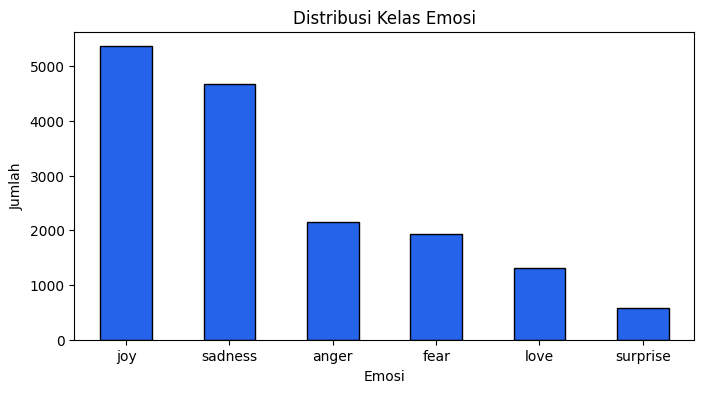

In [ ]:
df["emotion"].value_counts().plot(
    kind="bar",
    figsize=(8,4),
    color="#2563EB",
    edgecolor="black"
)

plt.title("Distribusi Kelas Emosi")
plt.xlabel("Emosi")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

## Data Preprocessing

In [ ]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text"])

sequences = tokenizer.texts_to_sequences(df["text"])

In [ ]:
first_10_words = dict(list(tokenizer.word_index.items())[:10])

In [ ]:
X = pad_sequences(sequences, maxlen=50, padding="post")
X.shape

(15999, 50)

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["emotion"])
label_encoder.classes_

array(['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'],
      dtype=object)

## Data Splitting

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1,
    random_state=42,
)

## Model Training

In [ ]:
model = tf.keras.Sequential([
    # Layer 1: Mengubah nomor kata menjadi vektor 64 dimensi
    tf.keras.layers.Embedding(input_dim=10000, output_dim=64, input_length=50),

    # Layer 2: Bi-LSTM membaca urutan kata maju dan mundur
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),

    # Layer 3: Mencegah hafalan (overfitting)
    tf.keras.layers.Dropout(0.3),

    # Layer 4: Penentuan klasifikasi 6 emosi
    tf.keras.layers.Dense(len(label_encoder.classes_), activation="softmax")
])

callback_stop = EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.fit(X,
          y,
          epochs=50,
          batch_size=15,
          callbacks=[callback_stop],
          validation_data=(X_val, y_val),
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.5868 - loss: 1.0921 - val_accuracy: 0.8243 - val_loss: 0.5521
Epoch 2/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8881 - loss: 0.3625 - val_accuracy: 0.9521 - val_loss: 0.1736
Epoch 3/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9396 - loss: 0.1948 - val_accuracy: 0.9660 - val_loss: 0.1005
Epoch 4/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9534 - loss: 0.1385 - val_accuracy: 0.9806 - val_loss: 0.0641
Epoch 5/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9653 - loss: 0.1035 - val_accuracy: 0.9771 - val_loss: 0.0612
Epoch 6/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.9745 - loss: 0.0749 - val_accuracy: 0.9882 - val_loss: 0.0352
Epoch 7/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9789 - loss: 0.0634 - val_accuracy: 0.9910 - val_loss: 0.0307
Epoch 8/50
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.9816 -

## Model Testing

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Hasil Evaluasi Test Set:")
print(f"Loss     : {test_loss:.4f}")
print(f"Accuracy : {test_accuracy * 100:.2f}%\n")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9931 - loss: 0.0181
Hasil Evaluasi Test Set:
Loss     : 0.0181
Accuracy : 99.31%



50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


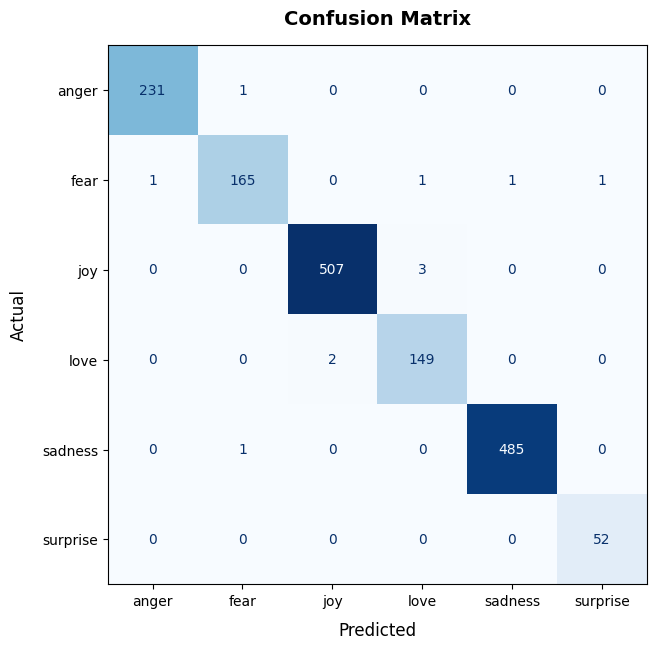

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = label_encoder.classes_

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# isualisasi Confusion Matrix menggunakan Matplotlib
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

plt.title("Confusion Matrix", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted", fontsize=12, labelpad=10)
plt.ylabel("Actual", fontsize=12, labelpad=10)
plt.grid(False)  # Mematikan garis grid agar tampilan matriks bersih
plt.show()

In [ ]:
def predict_emotion(text, model, tokenizer, label_encoder, max_len=50):
    # 1. Mengubah teks input menjadi urutan token ID
    sequence = tokenizer.texts_to_sequences([str(text).lower()])

    # 2. Menyamakan panjang sequence menjadi 50 kata
    padded = pad_sequences(sequence, maxlen=max_len, padding="post", truncating="post")

    # 3. Melakukan inferensi prediksi
    prediction_probs = model.predict(padded, verbose=0)[0]
    predicted_index = np.argmax(prediction_probs)
    predicted_emotion = label_encoder.inverse_transform([predicted_index])[0]
    confidence = prediction_probs[predicted_index] * 100

    return predicted_emotion, confidence

# --- Contoh Pengujian ---
contoh_kalimat = "Im crying a lot that day"
emosi, keyakinan = predict_emotion(contoh_kalimat, model, tokenizer, label_encoder)

print(f"Kalimat   : \"{contoh_kalimat}\"")
print(f"Prediksi  : {emosi.upper()} (Tingkat Keyakinan: {keyakinan:.2f}%)")

Kalimat   : "Im crying a lot that day"
Prediksi  : SADNESS (Tingkat Keyakinan: 60.60%)
